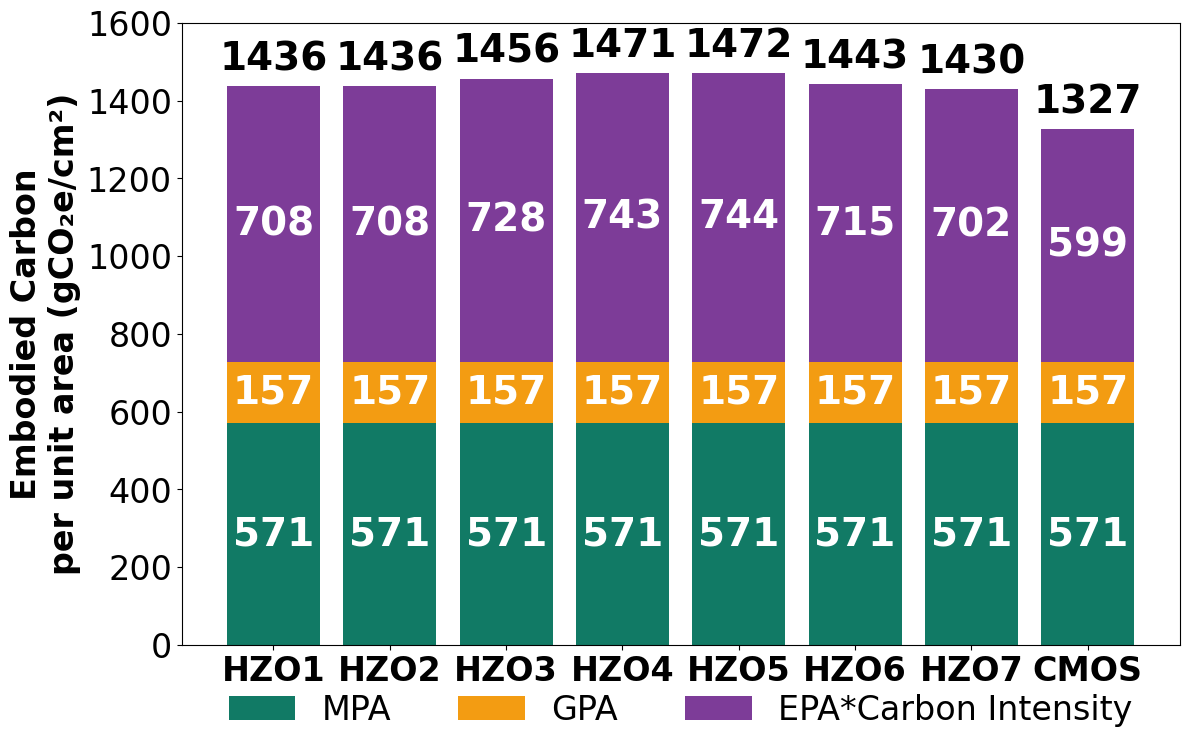

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 1. Input parameters
# ----------------------------
fel_epa_values = {
    "HZO1": 0.16960256,
    "HZO2": 0.16960256,
    "HZO3": 0.20136991,
    "HZO4": 0.2253082,
    "HZO5": 0.2254863,
    "HZO6": 0.18070274,
    "HZO7": 0.16069758,
}
factor = 0.96079
GPA = 157
MPA = 571

# ----------------------------
# 2. Calculate EPA and components
# ----------------------------
devices = list(fel_epa_values.keys())
epa_values = {dev: 0.9 + factor * v for dev, v in fel_epa_values.items()}
epa_term = [(epa * 583) /0.875 for epa in epa_values.values()]
gpa_term = [GPA] * len(devices)
mpa_term = [MPA] * len(devices)

# CMOS baseline
epa_cmos = 0.9
epa_term_cmos = (epa_cmos * 583)/0.875
devices.append("CMOS")
epa_term.append(epa_term_cmos)
gpa_term.append(GPA)
mpa_term.append(MPA)

totals = [m + g + e for e, g, m in zip(epa_term, gpa_term, mpa_term)]

# ----------------------------
# 3. Plot stacked bar chart
# ----------------------------
x = np.arange(len(devices))

fig, ax = plt.subplots(figsize=(12, 8))

color_epa = "#7D3C98"   # Deep purple
color_gpa = "#F39C12"   # Orange
color_mpa = "#117A65"   # Deep Green

# MPA at the bottem
bars_mpa = ax.bar(x, mpa_term, label="MPA", color=color_mpa)
# GPA at the middle
bars_gpa = ax.bar(x, gpa_term, bottom=mpa_term, label="GPA", color=color_gpa)
# EPA*Carbon Intensity at the top
bars_epa = ax.bar(x, epa_term, bottom=[m+g for m,g in zip(mpa_term, gpa_term)],
                  label="EPA*Carbon Intensity", color=color_epa)

# Total value (black)
for i, total in enumerate(totals):
    ax.text(x[i], total + 20, f"{int(total)}",
            ha='center', va='bottom', fontsize=28, fontweight="bold", color="black")

# Value for each part (white)
for rect, val in zip(bars_mpa, mpa_term):
    ax.text(rect.get_x() + rect.get_width()/2., val/2, f"{val}",
            ha='center', va='center', fontsize=28, color="white", fontweight="bold")

for rect, val_m in zip(bars_gpa, mpa_term):
    bottom = val_m
    ax.text(rect.get_x() + rect.get_width()/2., bottom + GPA/2, f"{GPA}",
            ha='center', va='center', fontsize=28, color="white", fontweight="bold")

for rect, val_tot in zip(bars_epa, totals):
    bottom = val_tot - rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., bottom + rect.get_height()/2,
            f"{int(rect.get_height())}", ha='center', va='center',
            fontsize=28, color="white", fontweight="bold")

# Labels and formatting
ax.set_xticks(x)
ax.tick_params(axis="y", labelsize=24)
ax.set_xticklabels(devices, fontsize=24, fontweight="bold")
ax.set_ylabel("Embodied Carbon\nper unit area (gCO₂e/cm²)", fontsize=24, fontweight="bold")
ax.set_yticks([0, 200, 400, 600, 800, 1000, 1200, 1400,1600])

ax.grid(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.03), ncol=3, fontsize=24, frameon=False)

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()


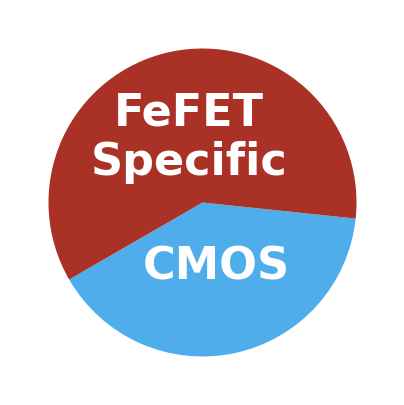

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data: Blue 40%, Red 60%
sizes = [0.4, 0.6]
colors = ["#4fadeb", "#a93125"]  # Blue=CMOS, Red=FeFET Specific
labels = ["CMOS", "FeFET\nSpecific"]

# Plot pie chart
fig, ax = plt.subplots(figsize=(5, 5))
wedges, _ = ax.pie(
    sizes,
    colors=colors,
    startangle=210,     # Red at the top
    labels=None         # No external labels
)

# Add text in the middle of each wedge
for i, w in enumerate(wedges):
    angle = (w.theta2 + w.theta1) / 2.0  # Center angle of the wedge
    x = np.cos(np.deg2rad(angle)) * 0.43  # Slightly reduced radius
    y = np.sin(np.deg2rad(angle)) * 0.43
    ax.text(x, y, labels[i],
            ha='center', va='center',
            fontsize=32, fontweight='bold', color="white")

plt.show()


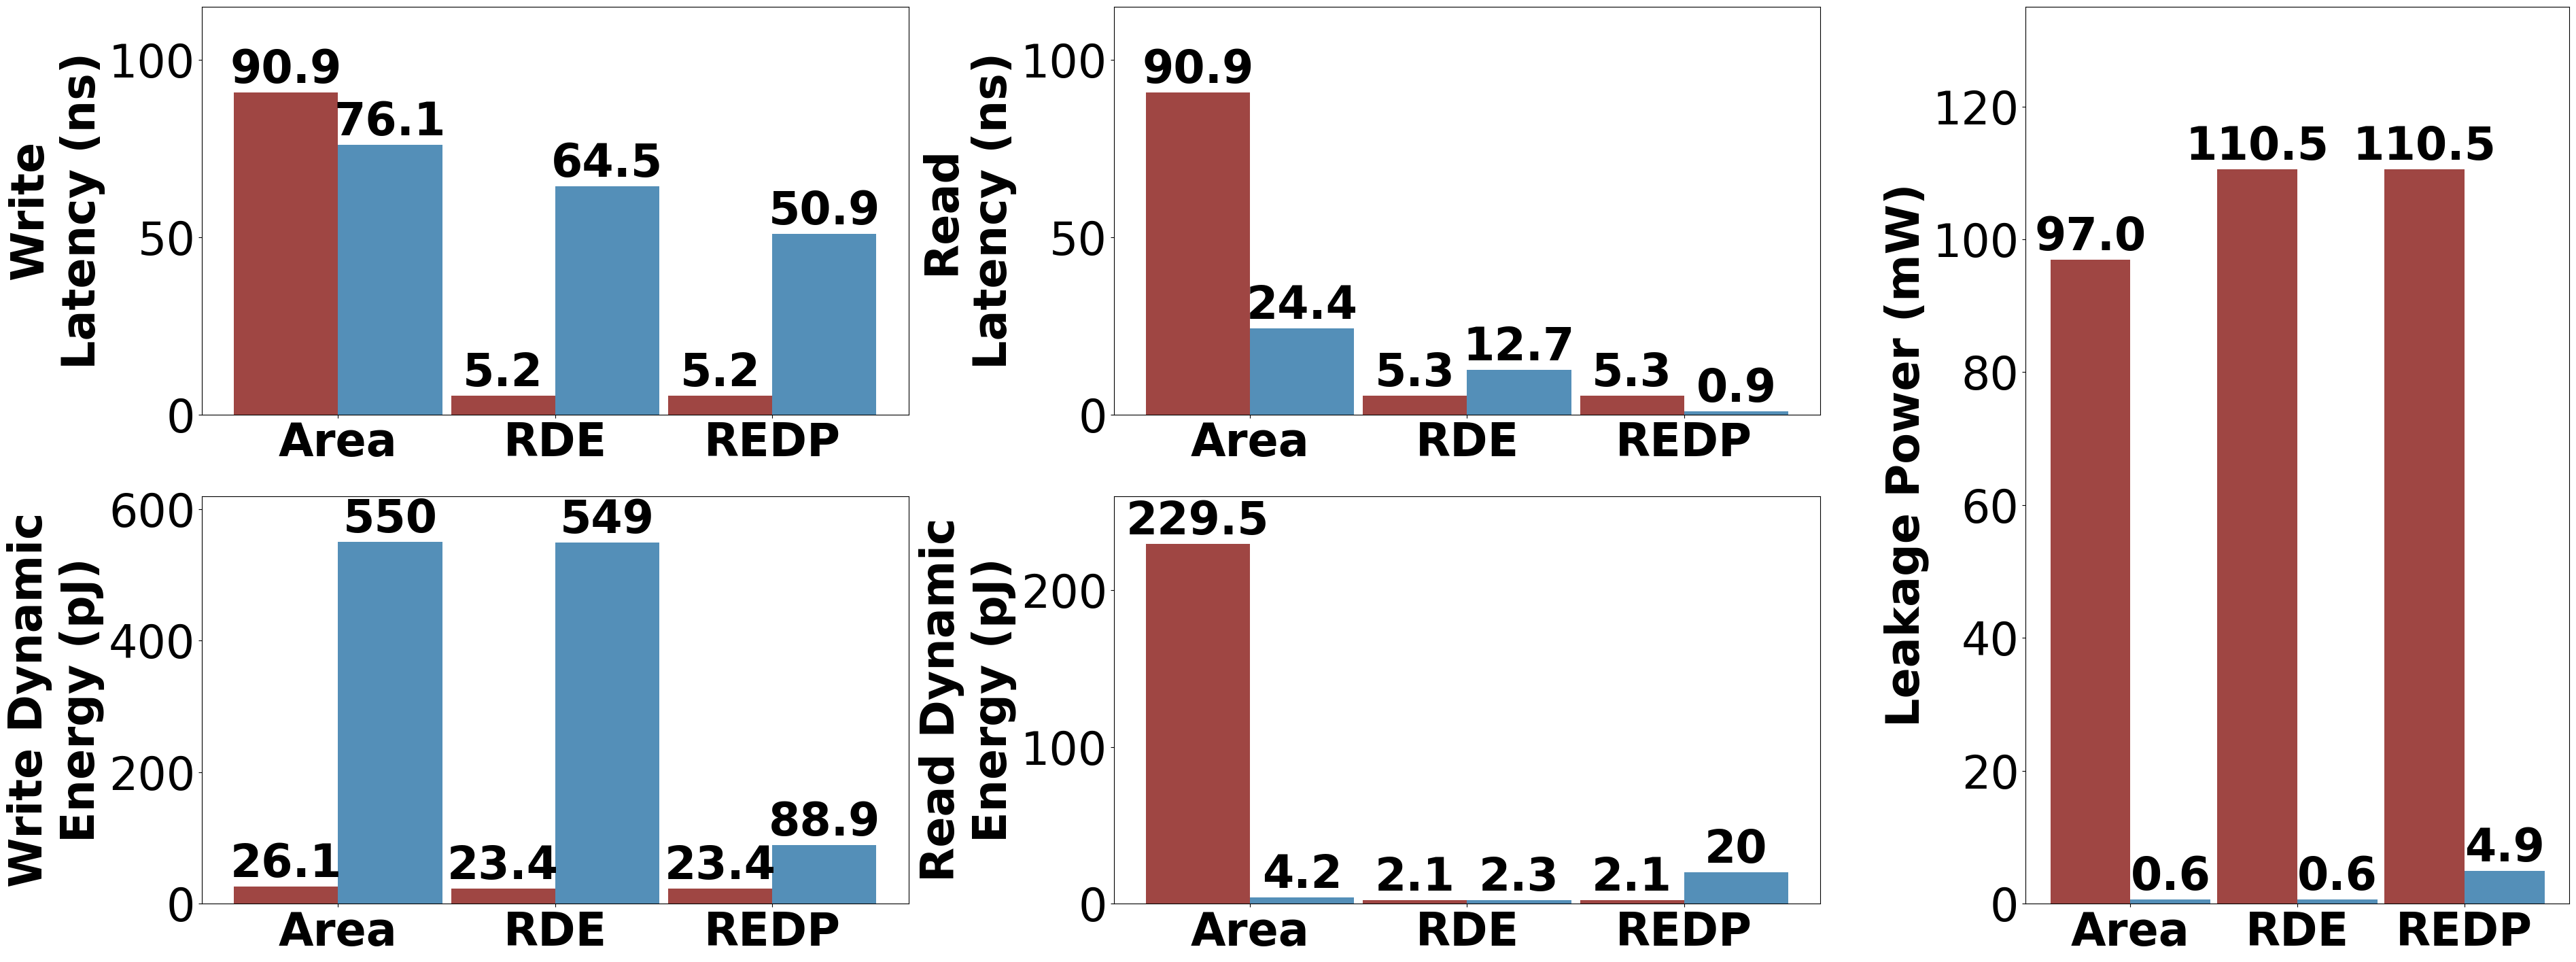

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import pandas as pd
import matplotlib.gridspec as gridspec
# -----------------------------
# Keep your data_dict & plot_data unchanged
# -----------------------------

data_dict = [
    # SRAM
    {"Device": "SRAM 2MB", "Opt Target": "Area",
     "Leakage Power (mW)": 96.97, "Write Latency (ns)": 90.903, "Read Dynamic Energy (pJ)": 229.516,
     "Write Dynamic Energy (pJ)": 26.08, "Read Latency (ns)": 90.91,
     "Area (mm²)": 1.944,
     "Embodied Carbon (CMOS) (gCO2e)": 2583.1872,
     "Operation Carbon per Write Access (gCO2e)": 1.431801e-15,
     "Operation Carbon per Read Access (gCO2e)": 1.464856e-15},

    {"Device": "SRAM 2MB", "Opt Target": "RDE",
     "Leakage Power (mW)": 110.516, "Write Latency (ns)": 5.246, "Read Dynamic Energy (pJ)": 2.132,
     "Write Dynamic Energy (pJ)": 23.38, "Read Latency (ns)": 5.253,
     "Area (mm²)": 2.109,
     "Embodied Carbon (CMOS) (gCO2e)": 2802.4392,
     "Operation Carbon per Write Access (gCO2e)": 9.767678e-17,
     "Operation Carbon per Read Access (gCO2e)": 9.436058e-17},

    {"Device": "SRAM 2MB", "Opt Target": "REDP",
     "Leakage Power (mW)": 110.516, "Write Latency (ns)": 5.246, "Read Dynamic Energy (pJ)": 2.132,
     "Write Dynamic Energy (pJ)": 23.38, "Read Latency (ns)": 5.253,
     "Area (mm²)": 2.109,
     "Embodied Carbon (CMOS) (gCO2e)": 2802.4392,
     "Operation Carbon per Write Access (gCO2e)": 9.767678e-17,
     "Operation Carbon per Read Access (gCO2e)": 9.436058e-17},

    # HZO5 FeFET (30F^2)
    {"Device": "HZO5 FeFET (30F^2) 2MB", "Opt Target": "Area",
     "Leakage Power (mW)": 0.6167, "Write Latency (ns)": 76.079, "Read Dynamic Energy (pJ)": 4.2,
     "Write Dynamic Energy (pJ)": 550, "Read Latency (ns)": 24.38,
     "Area (mm²)": 0.4107,
     "Embodied Carbon (CMOS) (gCO2e)": 670.748024,
     "Operation Carbon per Write Access (gCO2e)": 9.670561e-17,
     "Operation Carbon per Read Access (gCO2e)": 3.115232e-18},

    {"Device": "HZO5 FeFET (30F^2) 2MB", "Opt Target": "RDE",
     "Leakage Power (mW)": 0.6168, "Write Latency (ns)": 64.452, "Read Dynamic Energy (pJ)": 2.3,
     "Write Dynamic Energy (pJ)": 549, "Read Latency (ns)": 12.66,
     "Area (mm²)": 0.4114,
     "Embodied Carbon (CMOS) (gCO2e)": 671.790417,
     "Operation Carbon per Write Access (gCO2e)": 9.545582e-17,
     "Operation Carbon per Read Access (gCO2e)": 1.640250e-18},

    {"Device": "HZO5 FeFET (30F^2) 2MB", "Opt Target": "REDP",
     "Leakage Power (mW)": 4.943, "Write Latency (ns)": 50.91, "Read Dynamic Energy (pJ)": 20,
     "Write Dynamic Energy (pJ)": 88.88, "Read Latency (ns)": 0.86,
     "Area (mm²)": 0.4918,
     "Embodied Carbon (CMOS) (gCO2e)": 790.360537,
     "Operation Carbon per Write Access (gCO2e)": 5.514728e-17,
     "Operation Carbon per Read Access (gCO2e)": 3.926870e-18},
]

plot_data = pd.DataFrame(data_dict)


metrics = [
    "Write Latency (ns)",
    "Write Dynamic Energy (pJ)",
    "Read Latency (ns)",
    "Read Dynamic Energy (pJ)",
    "Leakage Power (mW)",
]

label_map = {
    "Write Latency (ns)": "Write\nLatency (ns)",
    "Write Dynamic Energy (pJ)": "Write Dynamic\nEnergy (pJ)",
    "Read Latency (ns)": "Read\nLatency (ns)",
    "Read Dynamic Energy (pJ)":"Read Dynamic\nEnergy (pJ)",
    "Leakage Power (mW)":"Leakage Power (mW)",
}


fig = plt.figure(figsize=(38, 15))

# Outer grid: 1 row
outer = fig.add_gridspec(1, 3, width_ratios=[1.3, 1.3, 1])  # Right side slightly wider

# Left side: 2 rows 1 column (equal height)
gs_left = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer[0], height_ratios=[1, 1]
)

# Middle: 2 rows 1 column (equal height)
gs_middle = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer[1], height_ratios=[1, 1]
)
# Right side: 1 row 1 column
gs_right = gridspec.GridSpecFromSubplotSpec(
    1, 1, subplot_spec=outer[2]
)

# Left subplots
ax_write_lat = fig.add_subplot(gs_left[0])  # Write Latency
ax_read_lat  = fig.add_subplot(gs_left[1])  # Read Latency

# Middle subplots
ax_leakage   = fig.add_subplot(gs_middle[0])  # Leakage Power
ax_write_dyn = fig.add_subplot(gs_middle[1])  # Write Dynamic Energy

# Right subplot
ax_read_dyn  = fig.add_subplot(gs_right[0])  # Read Dynamic Energy

axes = [
    ax_write_lat,
    ax_read_lat,
    ax_leakage,
    ax_write_dyn,
    ax_read_dyn
]
# -----------------------------
# Plotting loop (keep your plotting logic, just use the new axes order)
# -----------------------------
color_sram = "#9F4643"  # Red
color_hzo5 = "#548FB8"  # Blue
opt_targets = ["Area", "RDE", "REDP"]

for idx, (metric, ax) in enumerate(zip(metrics, axes)):
    width = 0.48
    x = np.arange(len(opt_targets))

    y_sram = [
        plot_data[(plot_data["Device"] == "SRAM 2MB") & (plot_data["Opt Target"] == t)][metric].values[0]
        for t in opt_targets
    ]
    y_hzo5 = [
        plot_data[(plot_data["Device"] == "HZO5 FeFET (30F^2) 2MB") & (plot_data["Opt Target"] == t)][metric].values[0]
        for t in opt_targets
    ]

    bars1 = ax.bar(x - width/2, y_sram, width, label="SRAM" if idx == 0 else "", color=color_sram)
    bars2 = ax.bar(x + width/2, y_hzo5, width, label="HZO5" if idx == 0 else "", color=color_hzo5)

    # Labels on top
    for bar in bars1 + bars2:
        h = bar.get_height()
        if abs(h - round(h)) < 1e-6:
            label = f"{int(round(h))}"
        else:
            label = f"{h:.1f}"
        ax.text(bar.get_x() + bar.get_width()/2, h, label,
                ha='center', va='bottom', fontsize=48, fontweight="bold")

    ylabel = label_map.get(metric, metric)
    ax.set_ylabel(ylabel, fontsize=48, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(opt_targets, ha="center", fontsize=48, fontweight="bold")
    ax.tick_params(axis="y", labelsize=48)

    if "Write Dynamic Energy" in metric:
        ax.set_ylim(0, 620)   # For W Dynamic Energy
    elif "Read Dynamic Energy" in metric:
        ax.set_ylim(0, 260)   # For R Dynamic Energy
    elif "Write Latency" in metric:
        ax.set_ylim(0, 115)
    elif "Read Latency" in metric:
        ax.set_ylim(0, 115)   # For Latency
    elif "Leakage" in metric:
        ax.set_ylim(0, 135)   # For Leakage


plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

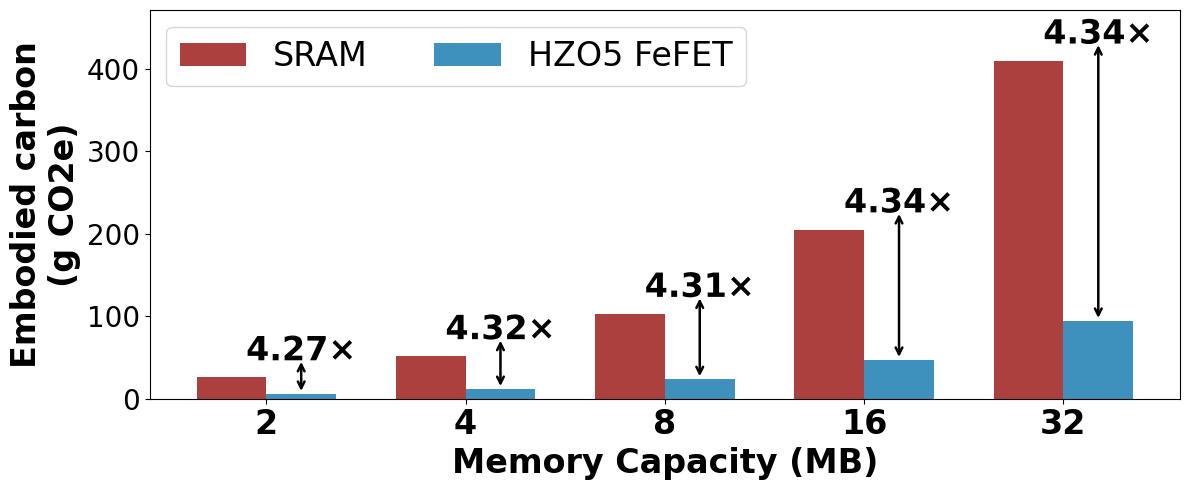

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Data
capacities = [2, 4, 8, 16, 32]
hzo5_vals = [6.05, 11.92, 23.83, 47.28, 94.55]   # HZO5 FeFET
sram_vals = [25.83, 51.48, 102.77, 205.27, 410.07]  # SRAM

x = np.arange(len(capacities))
width = 0.35

# Plotting
fig, ax = plt.subplots(figsize=(12,5))
bars1 = ax.bar(x - width/2, sram_vals, width, label="SRAM", color="#ac403f")
bars2 = ax.bar(x + width/2, hzo5_vals, width, label="HZO5 FeFET", color="#3d91bc")


# y-axis linear scale, fixed upper limit 430
ax.set_ylim(0, 430)

# Axes and title
ax.set_xlabel("Memory Capacity (MB)", fontsize=24, fontweight="bold")
ax.set_ylabel("Embodied carbon\n(g CO2e)", fontsize=24, fontweight="bold")

# x-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(capacities, fontsize=24, fontweight="bold")

# y-axis tick font
ax.tick_params(axis='y', labelsize=20)

# Remove background grid
ax.grid(False)



# Make space for text/arrows at the top
y_max = max(hzo5_vals + sram_vals)
headroom = y_max * 0.15
ax.set_ylim(0, y_max + headroom)

for i, (v_fefet, v_sram) in enumerate(zip(hzo5_vals, sram_vals)):
    ratio = v_sram / v_fefet

    # Place text directly above the HZO5 bar
    x_hzo5 = x[i] + width/2
    y_text = max(v_fefet, v_sram) + headroom * 0.2
    ax.text(
        x_hzo5, y_text, f"{ratio:.2f}×",
        ha='center', va='bottom', fontsize=24, fontweight='bold', color='black',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')]
    )

    # Vertical double-headed arrow: top end near text, bottom end pointing to HZO5 bar top
    y_top = y_text+10          # Slightly below the text
    y_bottom = v_fefet                   # Slightly above bar top to avoid overlap
    ax.annotate(
        "",
        xy=(x_hzo5, y_bottom), xytext=(x_hzo5, y_top),
        arrowprops=dict(arrowstyle="<->", lw=1.8, mutation_scale=12),
        annotation_clip=False  # Draw even if outside axes
    )

# Legend
ax.legend(fontsize=24, loc="upper left",ncol=2)

# Complete the top and right spines
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

In [ ]:
pip install brokenaxes

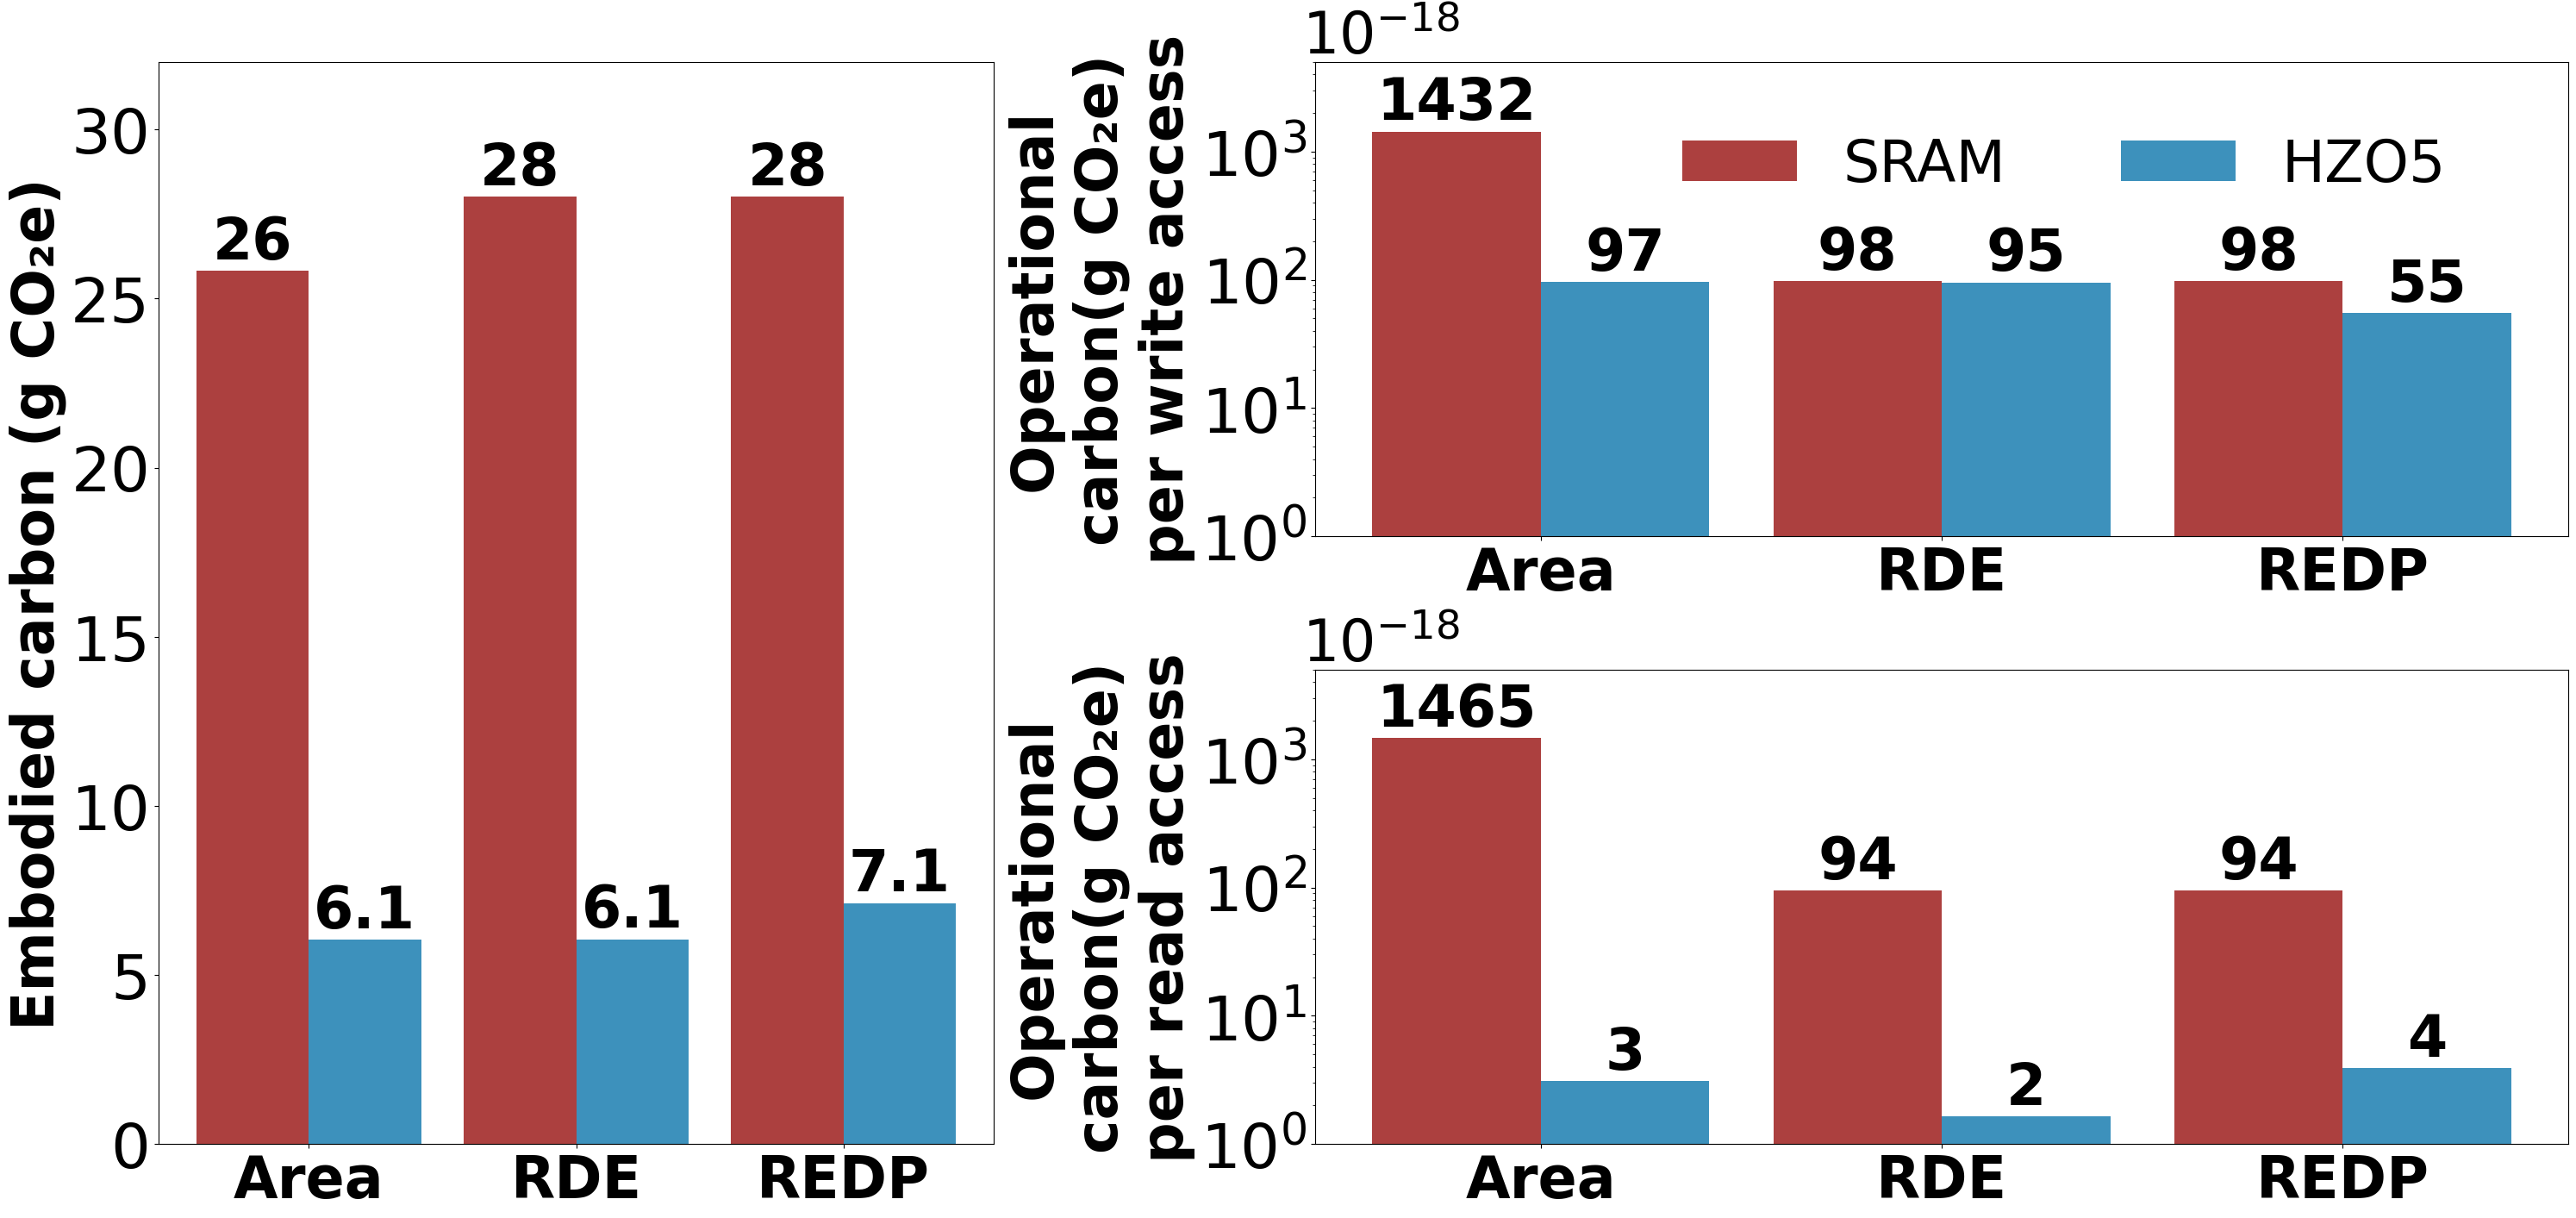

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import pandas as pd
from matplotlib.ticker import FuncFormatter

# -----------------------------
# Data table (hardcoded)
# -----------------------------
data_dict = [
    # SRAM
    {"Device": "SRAM 2MB", "Opt Target": "Area",
     "Leakage Power (mW)": 15.6, "Write Latency (ns)": 0.42, "Read Dynamic Energy (pJ)": 0.88,
     "Write Dynamic Energy (pJ)": 26.08, "Read Latency (ns)": 90.91,
     "Embodied Carbon (gCO2e)": 25.831872,
     "Operation Carbon per Write Access (gCO2e)": 1.431801e-15,
     "Operation Carbon per Read Access (gCO2e)": 1.464856e-15},

    {"Device": "SRAM 2MB", "Opt Target": "RDE",
     "Leakage Power (mW)": 15.2, "Write Latency (ns)": 0.39, "Read Dynamic Energy (pJ)": 0.75,
     "Write Dynamic Energy (pJ)": 23.38, "Read Latency (ns)": 5.25,
     "Embodied Carbon (gCO2e)": 28.024392,
     "Operation Carbon per Write Access (gCO2e)": 9.767678e-17,
     "Operation Carbon per Read Access (gCO2e)": 9.436058e-17},

    {"Device": "SRAM 2MB", "Opt Target": "REDP",
     "Leakage Power (mW)": 16.0, "Write Latency (ns)": 0.45, "Read Dynamic Energy (pJ)": 0.92,
     "Write Dynamic Energy (pJ)": 23.38, "Read Latency (ns)": 5.25,
     "Embodied Carbon (gCO2e)": 28.024392,
     "Operation Carbon per Write Access (gCO2e)": 9.767678e-17,
     "Operation Carbon per Read Access (gCO2e)": 9.436058e-17},

    # HZO5 FeFET (30F^2)
    {"Device": "HZO5 FeFET (30F^2) 2MB", "Opt Target": "Area",
     "Leakage Power (mW)": 0.52, "Write Latency (ns)": 1.9, "Read Dynamic Energy (pJ)": 1.2,
     "Write Dynamic Energy (pJ)": 550, "Read Latency (ns)": 24.38,
     "Embodied Carbon (gCO2e)": 6.050243,
     "Operation Carbon per Write Access (gCO2e)": 9.670561e-17,
     "Operation Carbon per Read Access (gCO2e)": 3.115232e-18},

    {"Device": "HZO5 FeFET (30F^2) 2MB", "Opt Target": "RDE",
     "Leakage Power (mW)": 0.50, "Write Latency (ns)": 1.7, "Read Dynamic Energy (pJ)": 1.1,
     "Write Dynamic Energy (pJ)": 549, "Read Latency (ns)": 12.66,
     "Embodied Carbon (gCO2e)": 6.059645,
     "Operation Carbon per Write Access (gCO2e)": 9.545582e-17,
     "Operation Carbon per Read Access (gCO2e)": 1.640250e-18},

    {"Device": "HZO5 FeFET (30F^2) 2MB", "Opt Target": "REDP",
     "Leakage Power (mW)": 0.55, "Write Latency (ns)": 2.0, "Read Dynamic Energy (pJ)": 1.3,
     "Write Dynamic Energy (pJ)": 88.88, "Read Latency (ns)": 0.86,
     "Embodied Carbon (gCO2e)": 7.129165,
     "Operation Carbon per Write Access (gCO2e)": 5.514728e-17,
     "Operation Carbon per Read Access (gCO2e)": 3.926870e-18},
]

plot_data = pd.DataFrame(data_dict)

# -----------------------------
# Plotting
# -----------------------------
color_sram = "#AC403F"  # Red
color_hzo5 = "#3D91BC"  # Blue

metrics = [
    "Embodied Carbon (gCO2e)",
    "Operation Carbon per Write Access (gCO2e)",
    "Operation Carbon per Read Access (gCO2e)"
]

opt_targets = ["Area", "RDE", "REDP"]

fig = plt.figure(figsize=(30, 15))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.5])  # Right side wider

# Two on the right
ax_right_top = fig.add_subplot(gs[0, 1])
ax_right_bottom = fig.add_subplot(gs[1, 1])

# One on the left (spanning two rows)
ax_left = fig.add_subplot(gs[:, 0])

# Map axes according to metrics order
axes = [ax_left, ax_right_top,ax_right_bottom]

# Define mapping for prettified labels
label_map = {
    "Embodied Carbon (gCO2e)": "Embodied carbon (g CO₂e)",
    "Operation Carbon per Write Access (gCO2e)": "Operational\ncarbon(g CO₂e)\nper write access",
    "Operation Carbon per Read Access (gCO2e)": "Operational\ncarbon(g CO₂e)\nper read access"
}

# Formatter (for text on top of bars)
formatter = LogFormatterMathtext()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    width = 0.42
    x = np.arange(len(opt_targets))

    # SRAM data
    y_sram = [
        plot_data[(plot_data["Device"] == "SRAM 2MB") & (plot_data["Opt Target"] == t)][metric].values[0]
        for t in opt_targets
    ]
    # HZO5 data
    y_hzo5 = [
        plot_data[(plot_data["Device"] == "HZO5 FeFET (30F^2) 2MB") & (plot_data["Opt Target"] == t)][metric].values[0]
        for t in opt_targets
    ]

    bars1 = ax.bar(x - width/2, y_sram, width,
                   label="SRAM" if idx == 0 else "", color=color_sram)
    bars2 = ax.bar(x + width/2, y_hzo5, width,
                   label="HZO5" if idx == 0 else "", color=color_hzo5)
    scale = 1e-18  # Extracted factor

    # Text on top
    for j, bar in enumerate(bars1 + bars2):
        h = bar.get_height()
        if "Operation Carbon" in metric:
            # Handle scaling
            label = f"{h/scale:.0f}"   # Show integers: 1, 10, 100...
        else:
            # Embodied Carbon remains normal
            label = f"{h:.2g}"
        ax.text(bar.get_x() + bar.get_width()/2, h, label,
                ha='center', va='bottom', fontsize=48, fontweight="bold")

    # y-axis settings
    ylabel = label_map.get(metric, metric)
    ax.set_ylabel(ylabel, fontsize=48, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(opt_targets,
                       ha="center", fontsize=48, fontweight="bold")
    ax.tick_params(axis="y", labelsize=52)

    # Embodied Carbon -> linear scale
    if metric == "Embodied Carbon (gCO2e)":
        ax.set_ylim(0, 32)

    elif metric == "Operation Carbon per Write Access (gCO2e)":
        scale = 1e-18

        ax.set_yscale("log")
        ax.set_ylim(1e-18, 5e-15)

        # Change to exponential form 10^n
        ax.yaxis.set_major_formatter(FuncFormatter(
            lambda y, _: r"$10^{%d}$" % np.log10(y/scale) if y > 0 else ""
        ))

        # Annotate ×10^-18 in the top left corner
        ax.annotate(r"$10^{-18}$",
            xy=(-0.015, 0.98), xycoords='axes fraction',
            xytext=(5, 5), textcoords='offset points',
            ha='left', va='bottom',
            fontsize=48, fontweight="bold")

    elif metric == "Operation Carbon per Read Access (gCO2e)":
        ax.set_yscale("log")
        ax.set_ylim(1e-18, 5e-15)

        # Change to exponential form 10^n
        ax.yaxis.set_major_formatter(FuncFormatter(
            lambda y, _: r"$10^{%d}$" % np.log10(y/scale) if y > 0 else ""
        ))

        # Annotate ×10^-18 in the top left corner
        ax.annotate(r"$10^{-18}$",
            xy=(-0.015, 0.98), xycoords='axes fraction',
            xytext=(5, 5), textcoords='offset points',
            ha='left', va='bottom',
            fontsize=48, fontweight="bold")

# Common legend
fig.legend(loc="upper center", bbox_to_anchor=(0.8, 0.93),
           ncol=2, fontsize=48, frameon=False)



plt.subplots_adjust(wspace=0.35, hspace=0.35)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

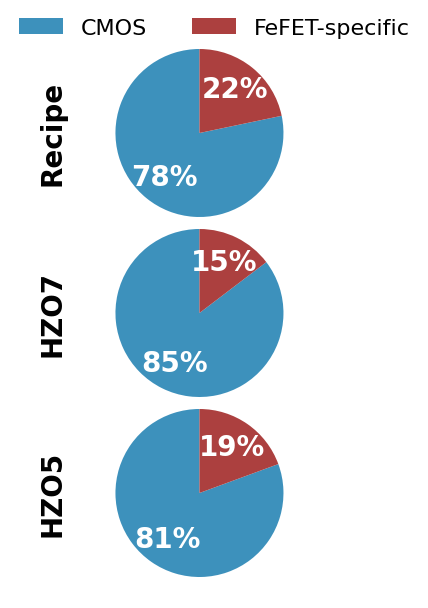

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

cmos = 0.9
fefet_default = 0.25985 * 0.96079
fefet_hzo7 = 0.16069 * 0.96079
fefet_hzo5 = 0.22549 * 0.96079

datasets = [
    ("Recipe", fefet_default, [0.1, 0.45, 0.35, 0.3]),  # [left, bottom, width, height]
    ("HZO7", fefet_hzo7, [0.1, 0.25, 0.35, 0.3]),
    ("HZO5", fefet_hzo5, [0.1, 0.05, 0.35, 0.3])
]

colors = ["#3D91BC","#AC403F" ]

fig = plt.figure(figsize=(6, 9))

for label, red_val, pos in datasets:
    ax = fig.add_axes(pos)   # Manually position subplot
    values = [cmos, red_val]
    wedges, texts, autotexts = ax.pie(
        values,
        colors=colors,
        autopct='%.0f%%',
        pctdistance=0.67,
        startangle=90,
        textprops={'fontsize': 20, 'weight': 'bold', 'color': 'white'}
    )

    ax.set_ylabel(label, fontsize=20, fontweight="bold", rotation=90, labelpad=20)


fig.legend(["CMOS", "FeFET-specific"], loc="upper center", bbox_to_anchor=(0.3, 0.75),ncol=2, fontsize=16, frameon=False)

plt.show()

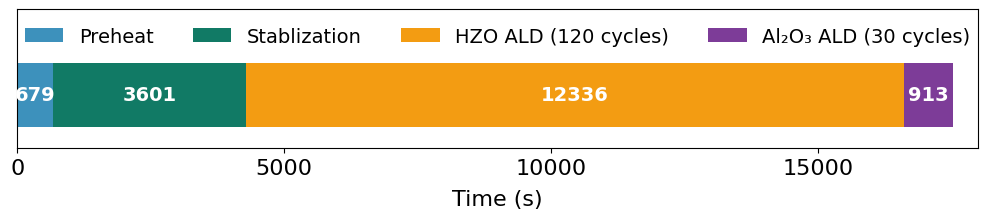

In [11]:
import matplotlib.pyplot as plt

# Data: Stages and durations
segments = [
    ("Preheat", 679),
    ("Stablization", 3601),
    ("HZO ALD (120 cycles)", 12336),
    ("Al₂O₃ ALD (30 cycles)", 913),
]
colors = ["#3D91BC","#117A65","#F39C12","#7D3C98" ]

color_epa = "#7D3C98"   # Deep purple
color_gpa = "#F39C12"   # Orange
color_mpa = "#117A65"   # Deep green
fig, ax = plt.subplots(figsize=(11, 2.3))

start = 0
for (label, dur), color in zip(segments, colors):
    ax.barh(0, dur, left=start, height=0.6, color=color, edgecolor='none', label=label)
    ax.text(start + dur/2, 0, f"{dur}", va='center', ha='center', fontsize=14, color='white',fontweight="bold")
    start += dur

# Axes
ax.set_xlim(0, 18000)
ax.set_ylim(-0.5, 0.8)
ax.set_yticks([])
ax.set_xticks(range(0, 18001, 5000))
ax.tick_params(axis='x', labelsize=16)
ax.set_xlabel("Time (s)", fontsize=16, labelpad=8)
ax.tick_params(axis='x')

# Legend
ax.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1),fontsize=14,frameon=False)

# Spines on all four sides
for spine in ["top","right","bottom","left"]:
    ax.spines[spine].set_visible(True)

plt.tight_layout()
plt.show()

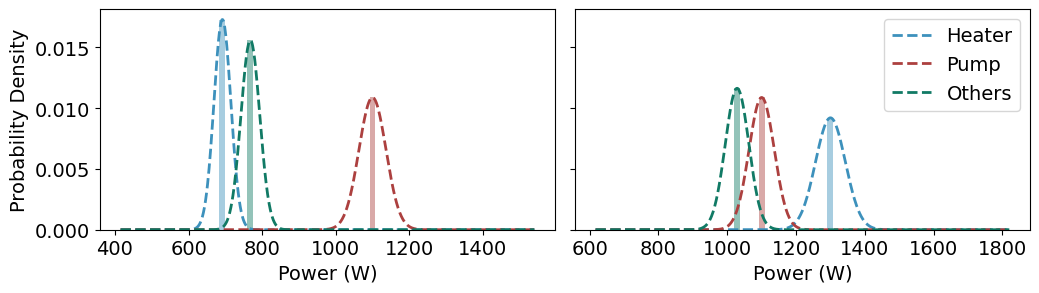

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_pdf_on_ax(ax, mus, labels, colors, show_ylabel=False):
    sigmas = [0.1*m/3 for m in mus]  # σ=10%/3
    xmin = min(mus)*0.6
    xmax = max(mus)*1.4
    x = np.linspace(xmin, xmax, 800)

    bar_width = (xmax - xmin) / 70
    lines = []
    for mu, sigma, color, lab in zip(mus, sigmas, colors, labels):
        pdf = norm.pdf(x, mu, sigma)
        line, = ax.plot(x, pdf, linestyle='--', linewidth=2, color=color, label=lab)
        ax.bar(mu, norm.pdf(mu, mu, sigma), width=bar_width, color=color, alpha=0.45)
        lines.append(line)

    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlabel("Power (W)",fontsize=14)

    if show_ylabel:
        ax.set_ylabel("Probability Density",fontsize=14)

    # Spines on all four sides
    for spine in ["top","right","bottom","left"]:
        ax.spines[spine].set_visible(True)

    return lines  # For unified legend

colors = ["#3D91BC", "#AC403F", "#117A65"]
#colors = ["#3D91BC", "#AC403F", "#62BD99"]
labels = ["Heater", "Pump", "Others"]

fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.2), sharey=True)

# Left: Stabilization phase
handles = plot_pdf_on_ax(
    axs[0],
    [692, 1100, 768],
    labels, colors,
    show_ylabel=True
)

# Right: Preheat phase
plot_pdf_on_ax(
    axs[1],
    [1300, 1100, 1028.57],
    labels, colors,
    show_ylabel=False
)

axs[1].legend(loc='upper right', fontsize=14, frameon=True)

# Leave some space for the top legend (no title, whitespace can be smaller)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()